Tadas Riksas 2312087 convnext_large Zebra Banana Parachute

In [3]:
pip install torch torchvision scikit-image numpy matplotlib==3.10.8 pandas openimages seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from torch import Generator
import torch
import pandas as pd
from skimage import io, transform
from skimage.color import gray2rgb
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from openimages.download import download_dataset
import torchvision.models as models
import glob
import torch.nn as nn   
from PIL import Image
from sklearn.metrics import classification_report
import seaborn as sns
import math


In [3]:
data_dir = "./project/data/"

# TODO - increase in production
number_of_samples = 334
classes = ["Ambulance", "Banana", "Parachute"]
mappings = [407, 954, 701]

NUM_CLASSES = len(classes)

if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    
print("Downloading data...")
# download_dataset(
#     data_dir,
#     classes,
#     limit=number_of_samples,
# )

In [4]:
IMAGE_SIZE = 380

base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

augment_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

In [5]:
def read_img(file_name):
    return Image.open(file_name).convert("RGB")

In [6]:
class MyImages(Dataset):
    def __init__(self, path, augment=False):
        self.path = path
        self.images = os.listdir(path)
        self.augment = augment

        self.class1_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[0].lower()))
        self.class2_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[1].lower()))
        self.class3_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[2].lower()))
        
        # include only the number of samples specified
        self.class1_files = self.class1_files[:number_of_samples]
        self.class2_files = self.class2_files[:number_of_samples]
        self.class3_files = self.class3_files[:number_of_samples]
        
        self.class1 = len(self.class1_files)
        self.class2 = len(self.class2_files)
        self.class3 = len(self.class3_files)
        
        self.files = self.class1_files + self.class2_files + self.class3_files
        
        self.labels = [0] * self.class1 + [1] * self.class2 + [2] * self.class3
        
        self.order = [x for x in np.random.permutation(len(self.files))]
        self.files = [self.files[i] for i in self.order]
        self.labels = [self.labels[i] for i in self.order]
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        img = read_img(self.files[idx])
        label = self.labels[idx]
        
        transform = augment_transform if self.augment else base_transform
        img = transform(img)
        return img, label


In [ ]:


TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
SEED = 1
BATCH_SIZE = 32

def get_dataloaders():
    full_dataset = MyImages(data_dir, augment=False)
    
    train_size = math.floor(TRAIN_SPLIT * len(full_dataset))
    val_size = math.floor(VAL_SPLIT * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size
    
    train_dataset = MyImages(data_dir, augment=True)
    val_dataset = MyImages(data_dir, augment=False)
    test_dataset = MyImages(data_dir, augment=False)
    
    train_ds, _, _ = random_split(train_dataset, [train_size, val_size, test_size], generator=Generator().manual_seed(SEED))
    _, val_ds, _ = random_split(val_dataset, [train_size, val_size, test_size], generator=Generator().manual_seed(SEED))
    _, _, test_ds = random_split(test_dataset, [train_size, val_size, test_size], generator=Generator().manual_seed(SEED))
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)
    
    return train_loader, val_loader, test_loader

In [35]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out
        
        
class MiniResNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = ResidualBlock(64, 64, stride=1)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x
    
        
        

In [36]:
NUM_EPOCHS    = 150
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "best_model.pth"

def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    training_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []
    
    best_val_acc = 0.0
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
            
        train_loss = running_loss / total_train
        train_accuracy = correct_train / total_train
        
        # Validation loop
        running_loss_v = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images  = images.to(DEVICE)
                labels  = labels.to(DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                running_loss_v += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss = running_loss_v / total_val
        val_acc = correct_val / total_val
        
        scheduler.step(val_loss)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            
        training_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_accuracy)
        val_acc_history.append(val_acc)
    
    return (training_loss_history, val_loss_history, train_acc_history, val_acc_history)


In [37]:
train_loader, val_loader, test_loader = get_dataloaders()
model = MiniResNet().to(DEVICE)
history = train_model(model, train_loader, val_loader)

In [38]:
def plot_training_history(history):
    training_loss_history, val_loss_history, train_acc_history, val_acc_history = history
    
    epochs = range(1, NUM_EPOCHS + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, training_loss_history, label='Training Loss')
    plt.plot(epochs, val_loss_history, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc_history, label='Training Accuracy')
    plt.plot(epochs, val_acc_history, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

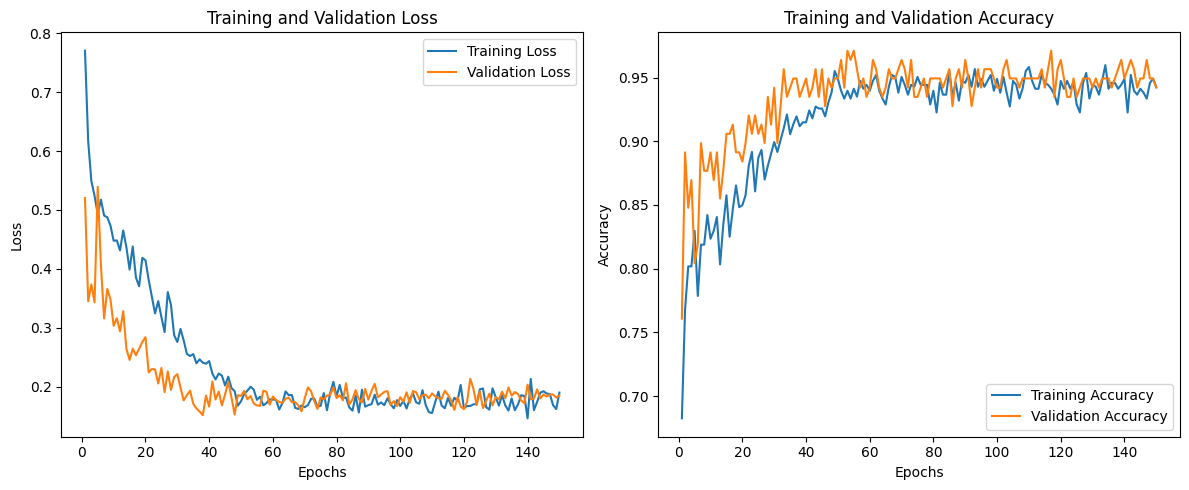

In [39]:
plot_training_history(history)

In [ ]:


from sklearn.metrics import confusion_matrix


model = MiniResNet(num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

model.to(DEVICE)

all_predictions, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_predictions.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())


all_predictions = np.concatenate(all_predictions)
all_labels = np.concatenate(all_labels) 

print("Predictions shape:", (all_predictions).shape)
print("Labels shape:", (all_labels).shape)

print(all_predictions)
print(all_labels)

Predictions shape: (139, 3)
Labels shape: (139,)
[[1.19747445e-01 7.42650688e-01 1.37601852e-01]
 [9.55577850e-01 4.36655693e-02 7.56586669e-04]
 [4.34941991e-04 5.59879874e-04 9.99005258e-01]
 [1.64182641e-08 1.00000000e+00 2.37786502e-08]
 [9.99811471e-01 1.02303318e-04 8.63242822e-05]
 [3.23576391e-01 1.41788974e-01 5.34634590e-01]
 [6.96064308e-05 3.42584935e-05 9.99896169e-01]
 [9.63786304e-01 1.66940931e-02 1.95196457e-02]
 [3.82677745e-03 9.78786588e-01 1.73866395e-02]
 [4.60252259e-03 9.93749142e-01 1.64837670e-03]
 [6.27572954e-01 3.40593785e-01 3.18333618e-02]
 [9.99362051e-01 5.21557929e-04 1.16391951e-04]
 [4.88280784e-03 8.81343782e-01 1.13773376e-01]
 [3.01761646e-02 7.22309351e-02 8.97593021e-01]
 [1.20629452e-01 5.28898044e-03 8.74081552e-01]
 [4.80619725e-04 9.98992503e-01 5.26927994e-04]
 [9.83781338e-01 1.15001593e-02 4.71852813e-03]
 [9.95675266e-01 1.48666266e-03 2.83811521e-03]
 [2.15872005e-01 7.68808365e-01 1.53195718e-02]
 [2.79283471e-04 9.99696493e-01 2.41964

              precision    recall  f1-score   support

   Ambulance       0.93      0.95      0.94        42
      Banana       1.00      0.87      0.93        45
   Parachute       0.91      1.00      0.95        52

    accuracy                           0.94       139
   macro avg       0.95      0.94      0.94       139
weighted avg       0.95      0.94      0.94       139



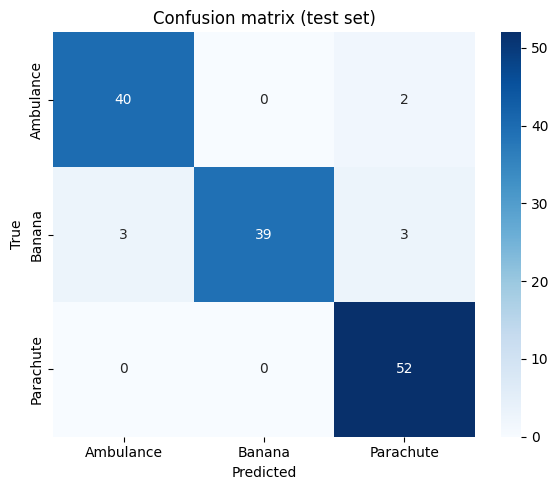

In [ ]:
all_pred_classes = np.argmax(all_predictions, axis=1)

print(classification_report(all_labels, all_pred_classes, target_names=classes))
cm = confusion_matrix(all_labels, all_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix (test set)')
plt.tight_layout()
plt.show()

In [41]:

def classify_with_threshold(predictions, true_labels, class_idx: int, threshold=0.5):
    """
    Classify samples based on threshold for a specific class
    # """
    
    # find indexes where true_labels == class_idx
    class_probs = predictions[:, class_idx]
    predicted = (class_probs >= threshold).astype(int)
    true = (true_labels == class_idx).astype(int)
    
    # Calculate metrics
    tp = np.sum((predicted == 1) & (true == 1))
    fp = np.sum((predicted == 1) & (true == 0))
    fn = np.sum((predicted == 0) & (true == 1))
    tn = np.sum((predicted == 0) & (true == 0))
    
    accuracy = (tp + tn) / len(true) if len(true) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:

T_list = np.concatenate([
    np.linspace(0.05, 0.7, 15),  
    np.linspace(0.7, 1, 15),
])
results = {class_name: [] for class_name in classes}

for j in range(3):
    for T in T_list:
        metrics = classify_with_threshold(
            all_predictions, 
            all_labels, 
            j,
            threshold=T
        )
        results[classes[j]].append(metrics['f1'])
    
    # Find optimal threshold
    idx = np.argmax(results[classes[j]])
    print(f"Optimal T={T_list[idx]:.2f} for {classes[j]} (F1={results[classes[j]][idx]:.3f})")

Optimal T=0.70 for Ambulance (F1=0.951)
Optimal T=0.28 for Banana (F1=0.977)
Optimal T=0.61 for Parachute (F1=0.981)


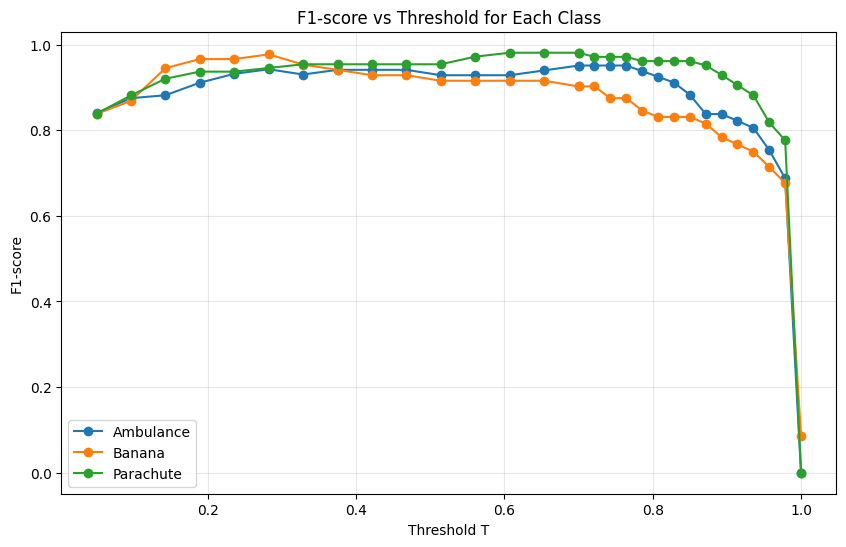

In [46]:
plt.figure(figsize=(10, 6))

for class_name in classes:
    plt.plot(T_list, results[class_name], marker='o', label=class_name)

plt.xlabel("Threshold T")
plt.ylabel("F1-score")
plt.title("F1-score vs Threshold for Each Class")
plt.legend()
plt.grid(True, alpha=0.3)
# limit y above 0.5 for better visualization
# plt.ylim(0.45, 1)
# plt.tight_layout()
plt.show()

In [47]:

# print(all_labels_concat[:10])
# print(all_predictions_concat[:, mappings][:10])
# print([np.max(all_predictions_concat[i]) for i in range(10)])

# # select classes with max probability
# for i in range(10):
#     predicted_class_idx = np.argmax(all_predictions_concat[i])
#     print(predicted_class_idx)

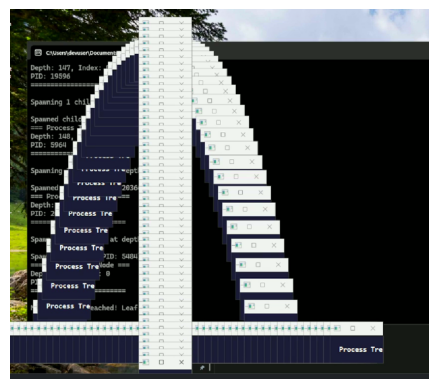

[[0.9080924  0.04765464 0.044253  ]]


In [48]:
# select one image not from the training set and test the model on it
# download an image of a house
# spec_img = "./project/train-station.jpg"
# spec_img = "./project/fundog.png"
# spec_img = "./project/bugdog.webp"
# spec_img = "./project/winfun.png"
spec_img = "./project/winfun.png"
image = io.imread(spec_img)
plt.imshow(image)
plt.axis('off')
plt.show()

# test model on the image
img_tensor = base_transform(read_img(spec_img)).unsqueeze(0).to(DEVICE)
probabilities = model(img_tensor)
probabilities = torch.nn.functional.softmax(probabilities, dim=1)
print(probabilities.detach().cpu().numpy())


# test autocomplete or not

In [ ]:
# ── Similarity search ────────────────────────────────────────────────────────

class FeatureExtractor(nn.Module):
    """Wrap MiniResNet, return the 256-d embedding instead of class logits."""
    def __init__(self, backbone: MiniResNet):
        super().__init__()
        # Keep everything up to (but not including) the final fc
        self.features = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3,
            backbone.avgpool,
        )
        self.dropout = backbone.dropout  # optional – omit for cleaner embeddings

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)          # (B, 256)
        x = nn.functional.normalize(x, dim=1)   # L2-normalise → cosine sim = dot
        return x


def build_feature_index(extractor, dataloader, device):
    """
    Encode every image in *dataloader* and return:
      embeddings  – np.ndarray (N, 256), L2-normalised
      file_paths  – list[str]  length N
      labels      – np.ndarray (N,)
    """
    extractor.eval()
    all_embs, all_labels, all_paths = [], [], []

    with torch.no_grad():
        for images, lbls in dataloader:
            embs = extractor(images.to(device))
            all_embs.append(embs.cpu().numpy())
            all_labels.append(lbls.numpy())

    embeddings = np.concatenate(all_embs, axis=0)   # (N, 256)
    labels     = np.concatenate(all_labels, axis=0)  # (N,)
    return embeddings, labels


def similarity_search(query_img_path, extractor, index_embeddings,
                      index_labels, device, top_k=5):
    """
    Given a path to a query image, return the top-k most similar images
    from the index together with their cosine similarity scores.
    """
    extractor.eval()
    with torch.no_grad():
        img_tensor = base_transform(read_img(query_img_path)).unsqueeze(0).to(device)
        query_emb  = extractor(img_tensor).cpu().numpy()   # (1, 256), normalised

    # Cosine similarity = dot product because both sides are L2-normalised
    sims = (index_embeddings @ query_emb.T).squeeze()      # (N,)

    top_k_idx = np.argsort(sims)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_k_idx):
        results.append({
            "rank":       rank + 1,
            "similarity": float(sims[idx]),
            "label":      classes[index_labels[idx]],
        })
    return results


def visualise_similarity_results(query_img_path, results, index_labels,
                                 index_embeddings, dataloader):
    """Quick matplotlib grid: query on the left, top-k neighbours on the right."""
    fig, axes = plt.subplots(1, len(results) + 1, figsize=(3 * (len(results) + 1), 3))

    query_img = io.imread(query_img_path)
    axes[0].imshow(query_img)
    axes[0].set_title("Query", fontsize=10)
    axes[0].axis("off")

    for ax, res in zip(axes[1:], results):
        ax.set_title(f"#{res['rank']}  {res['label']}\n{res['similarity']:.3f}",
                     fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# ── Usage ────────────────────────────────────────────────────────────────────

# 1. Load best model and build extractor
best_model = MiniResNet(num_classes=NUM_CLASSES)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE)

extractor = FeatureExtractor(best_model).to(DEVICE)

# 2. Build index from the *test* loader (or all data — your choice)
_, _, test_loader = get_dataloaders()
index_embeddings, index_labels = build_feature_index(extractor, test_loader, DEVICE)

print(f"Index built: {index_embeddings.shape}")   # e.g. (150, 256)

# 3. Run a query
query_path = "./project/winfun.png"          # swap for any image
results = similarity_search(
    query_path, extractor, index_embeddings, index_labels, DEVICE, top_k=5
)

for r in results:
    print(f"Rank {r['rank']:2d}  sim={r['similarity']:.4f}  class={r['label']}")